# c50py vs scikit-learn's CART: one question instead of a staircase

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daviddiazsolis/c50py/blob/main/examples/notebooks/02_c50py_vs_cart.ipynb)

scikit-learn's `DecisionTreeClassifier` (CART) only splits on numbers, so a categorical column has
to be one-hot encoded: one 0/1 column per category. A tree can then ask about one category at a
time, and a question like "is the sector one of mining, tourism or construction?" becomes a
staircase of three splits. C5.0 asks it in one.

This notebook compares the two on the same data, first on a small example where the difference is
easy to see, then on real datasets, with both trees pruned as well as cross-validation allows.
The comparison is meant to be fair: CART's cost-complexity pruning is tuned too.

In [1]:
# Colab / a fresh environment: install c50py (0.5 or later)
import importlib, subprocess, sys
try:
    import c50py
    assert tuple(int(v) for v in c50py.__version__.split(".")[:2]) >= (0, 5)
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "c50py>=0.5.0"], check=True)
    import c50py
    importlib.reload(c50py)
print("c50py", c50py.__version__)

c50py 0.5.0


In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree as sk_plot_tree
from c50py import C5Classifier

CV = StratifiedKFold(5, shuffle=True, random_state=0)

def tuned_cart(A, y):
    """CART with cost-complexity pruning (ccp_alpha) and min_samples_leaf chosen by 5-fold CV."""
    path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(A, y)
    alphas = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 0.98, 25)))
    grid = {"ccp_alpha": alphas, "min_samples_leaf": [1, 2, 5, 10]}
    return GridSearchCV(DecisionTreeClassifier(random_state=0), grid, cv=CV).fit(A, y).best_estimator_

def tuned_c50(X, y):
    """c50py with the confidence factor cf chosen by 5-fold CV."""
    return GridSearchCV(C5Classifier(), {"cf": [0.05, 0.1, 0.25, 0.5]}, cv=CV).fit(X, y).best_estimator_

## 1. The staircase, on a small example

3,000 loan applicants from eight sectors. Three sectors (mining, tourism, construction) default
far more often; a high debt ratio adds a little risk. The true structure is one question about
the sector.

In [3]:
rng = np.random.default_rng(7)
n = 3000
sectors = ["retail", "mining", "farming", "tech", "transport", "tourism", "health", "construction"]
df = pd.DataFrame({"sector": pd.Categorical(rng.choice(sectors, n)),
                   "debt_ratio": rng.uniform(0, 1, n).round(2)})
p = np.where(df.sector.isin(["mining", "tourism", "construction"]), 0.75, 0.2)
p = np.where(df.debt_ratio > 0.7, p + 0.2, p)
y = np.where(rng.uniform(size=n) < p, "default", "pays")
X_tr, X_te, y_tr, y_te = train_test_split(df, y, test_size=0.3, random_state=0, stratify=y)

dummies = lambda d: pd.get_dummies(d, columns=["sector"], dtype=int)
A_tr, A_te = dummies(X_tr), dummies(X_te)

cart = tuned_cart(A_tr, y_tr)
c5 = tuned_c50(X_tr, y_tr)
print(f"CART + one-hot: {cart.get_n_leaves()} leaves, test accuracy {cart.score(A_te, y_te):.3f}")
print(f"c50py:          {len(c5.export_rules())} leaves, test accuracy {c5.score(X_te, y_te):.3f}")

CART + one-hot: 10 leaves, test accuracy 0.788
c50py:          2 leaves, test accuracy 0.788


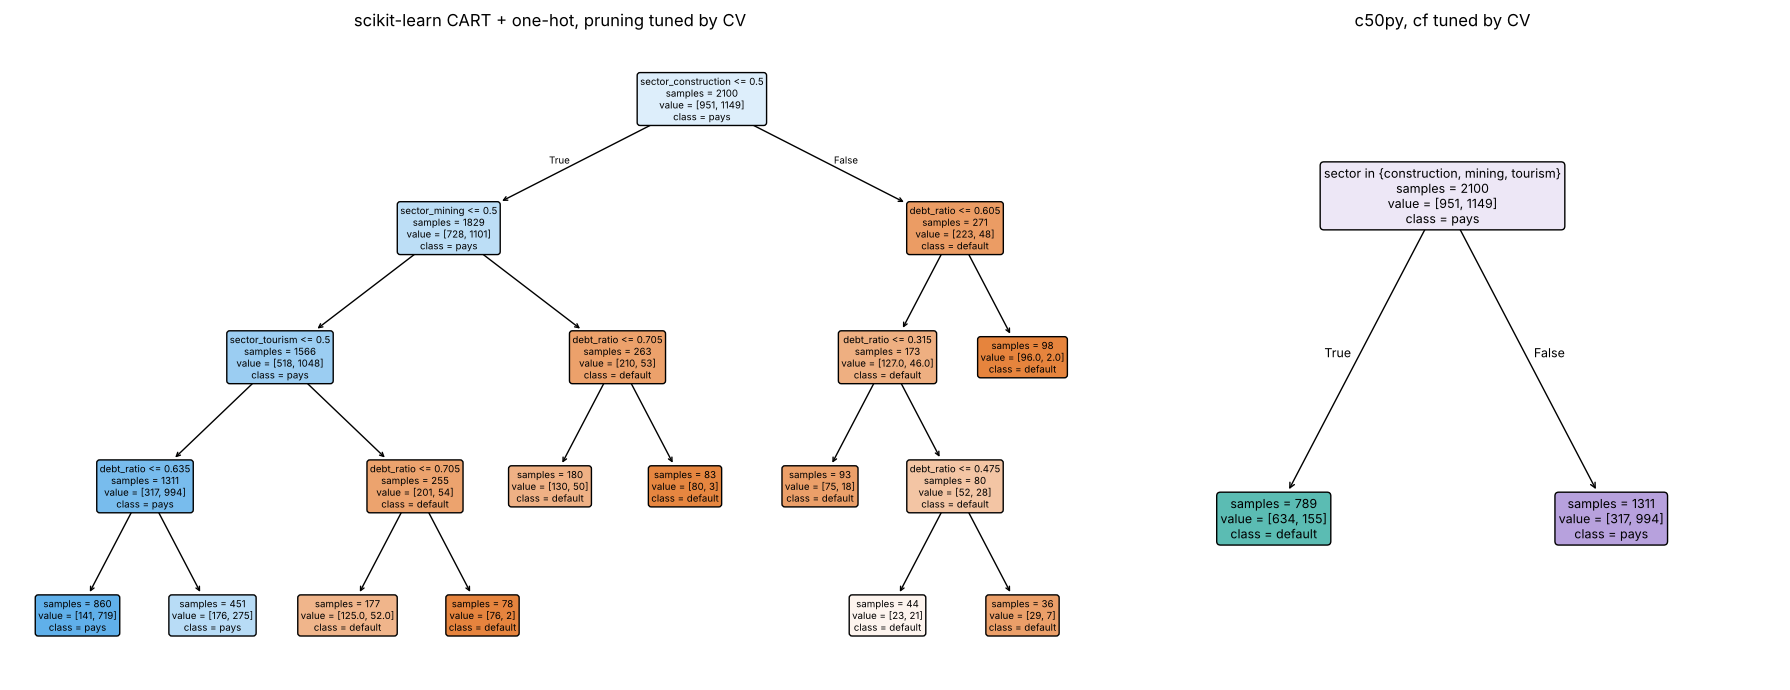

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1.6, 1]})
sk_plot_tree(cart, feature_names=list(A_tr.columns), class_names=list(cart.classes_), filled=True,
             rounded=True, impurity=False, fontsize=7, ax=axes[0])
axes[0].set_title("scikit-learn CART + one-hot, pruning tuned by CV")
c5.plot_tree(class_names=list(c5.classes_), filled=True, rounded=True, impurity=False, fontsize=9, ax=axes[1])
axes[1].set_title("c50py, cf tuned by CV")
plt.tight_layout(); plt.show()

Same accuracy, but CART needs three dummy columns, one after the other, to say what c50py says
with `sector in {construction, mining, tourism}`. The rules make it plainer:

In [5]:
from sklearn.tree import export_text
print("CART:\n" + export_text(cart, feature_names=list(A_tr.columns)))
print("c50py:")
for r in c5.export_rules():
    print("  " + r)

CART:
|--- sector_construction <= 0.50
|   |--- sector_mining <= 0.50
|   |   |--- sector_tourism <= 0.50
|   |   |   |--- debt_ratio <= 0.63
|   |   |   |   |--- class: pays
|   |   |   |--- debt_ratio >  0.63
|   |   |   |   |--- class: pays
|   |   |--- sector_tourism >  0.50
|   |   |   |--- debt_ratio <= 0.70
|   |   |   |   |--- class: default
|   |   |   |--- debt_ratio >  0.70
|   |   |   |   |--- class: default
|   |--- sector_mining >  0.50
|   |   |--- debt_ratio <= 0.70
|   |   |   |--- class: default
|   |   |--- debt_ratio >  0.70
|   |   |   |--- class: default
|--- sector_construction >  0.50
|   |--- debt_ratio <= 0.61
|   |   |--- debt_ratio <= 0.31
|   |   |   |--- class: default
|   |   |--- debt_ratio >  0.31
|   |   |   |--- debt_ratio <= 0.47
|   |   |   |   |--- class: default
|   |   |   |--- debt_ratio >  0.47
|   |   |   |   |--- class: default
|   |--- debt_ratio >  0.61
|   |   |--- class: default

c50py:
  sector IN {construction, mining, tourism} => defau

## 2. Real data

Four OpenML datasets with categorical columns. For each one, the two trees with default
settings and with their pruning tuned by cross-validation; we report test accuracy, the number of
leaves, the mean number of **distinct columns** a rule tests (what a person has to look at to
apply a rule) and the number of columns the tree uses. For CART, the dummies of one column count
as one column.

* `credit-g`: 1,000 loan applicants, 13 categorical and 7 numeric columns.
* `mushroom`: 8,124 mushrooms, all 21 columns categorical, edible or poisonous.
* `car`: 1,728 car evaluations, all 6 columns categorical, 4 classes.
* `churn`: 5,000 telecom customers, mostly numeric columns.

In [6]:
def leaf_stats_c50(m):
    depths, distinct, used = [], [], set()
    def walk(node, path):
        if node.is_leaf:
            depths.append(len(path)); distinct.append(len(set(path))); return
        used.add(node.feature_index)
        for ch in node.children.values():
            walk(ch, path + [node.feature_index])
    walk(m.tree_, [])
    return len(depths), np.mean(distinct), len(used)

def leaf_stats_cart(m, col_of):
    t, distinct, stack = m.tree_, [], [(0, ())]
    while stack:
        node, path = stack.pop()
        if t.children_left[node] == -1:
            distinct.append(len(set(path)))
        else:
            c = col_of[t.feature[node]]
            stack += [(t.children_left[node], path + (c,)), (t.children_right[node], path + (c,))]
    return m.get_n_leaves(), np.mean(distinct), len(set(col_of[t.feature[t.feature >= 0]]))

def load(data_id):
    d = fetch_openml(data_id=data_id, as_frame=True, parser="pandas")
    X = d.data.copy()
    for c in X.columns:
        if str(X[c].dtype) in ("object", "str", "string", "bool"):
            X[c] = X[c].astype("category")
    return d.details["name"], X, d.target.astype(str).to_numpy()

rows = []
for data_id in [31, 24, 40975, 40701]:
    name, X, y = load(data_id)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
    cats = [c for c in X.columns if str(X[c].dtype) == "category"]
    def onehot(D):
        D = D.copy()
        for c in cats:
            D[c] = D[c].astype(object).where(D[c].notna(), "missing")
        return pd.get_dummies(D, columns=cats, dtype=int)
    A_tr = onehot(X_tr); A_te = onehot(X_te).reindex(columns=A_tr.columns, fill_value=0)
    # map every dummy column back to its original column
    col_of = []
    for c in A_tr.columns:
        if c in X.columns:
            col_of.append(X.columns.get_loc(c))
        else:
            col_of.append(X.columns.get_loc(next(o for o in cats if c.startswith(o + "_"))))
    col_of = np.array(col_of)
    for label, m, Xt, Xe in [("CART + one-hot, defaults", DecisionTreeClassifier(random_state=0).fit(A_tr, y_tr), A_tr, A_te),
                             ("CART + one-hot, tuned", tuned_cart(A_tr, y_tr), A_tr, A_te),
                             ("c50py, defaults", C5Classifier().fit(X_tr, y_tr), X_tr, X_te),
                             ("c50py, tuned", tuned_c50(X_tr, y_tr), X_tr, X_te)]:
        stats = leaf_stats_cart(m, col_of) if "CART" in label else leaf_stats_c50(m)
        rows.append(dict(dataset=name, model=label, accuracy=round(m.score(Xe, y_te), 3), leaves=stats[0],
                         columns_per_rule=round(stats[1], 1), columns_used=stats[2]))
results = pd.DataFrame(rows)
results

,dataset,model,accuracy,leaves,columns_per_rule,columns_used
0,credit-g,"CART + one-hot, defaults",0.673,142,8.0,19
1,credit-g,"CART + one-hot, tuned",0.693,16,4.6,12
2,credit-g,"c50py, defaults",0.720,59,8.3,20
3,credit-g,"c50py, tuned",0.757,16,5.8,12
4,mushroom,"CART + one-hot, defaults",0.999,13,3.4,8
5,mushroom,"CART + one-hot, tuned",0.999,13,3.4,8
6,mushroom,"c50py, defaults",0.999,7,3.6,6
7,mushroom,"c50py, tuned",0.999,7,3.6,6
8,car,"CART + one-hot, defaults",0.971,79,5.6,6
9,car,"CART + one-hot, tuned",0.975,71,5.6,6


How to read it:

* **Against CART with its defaults** (one-hot and no pruning, which is how it is most often run)
  c50py's trees are between two and six times smaller, and at least as accurate: 59 leaves
  against 142 on `credit-g`, 36 against 231 on `churn`.
* **When the data are categorical** (`mushroom`, `car`) c50py's trees are also smaller than a well
  pruned CART, with about the same accuracy (7 leaves against 13, 51 against 71): grouping
  categories in one test is exactly what these data need.
* **On mixed data** the picture depends on the data. On `credit-g`, where the categorical columns
  carry much of the signal, the two tuned trees have the same 16 leaves but c50py is six points
  more accurate on this test split. On `churn`, which is mostly numeric, the tuned CART is a little
  smaller (29 leaves against 36) at the same accuracy: native categories do not help much when the
  categories are not where the signal is.

One test split of 300 or 1,500 cases is a noisy measure, so differences of a point or two should
not be read as a verdict. The package benchmark (`benchmarks/`) repeats this comparison with five
folds on 23 OpenML datasets and tests whether the differences are significant.

## 3. What the comparison does not show

Leaves and columns are rough measures of how easy a tree is to read. Two things matter as much and
favour C5.0 regardless of size: a categorical test is stated in the business's own terms
(`purpose IN {new car, education}`, not `purpose_new car <= 0.5`), and no preprocessing pipeline
has to be kept in sync with the model to apply it.